# AI-Powered Visual Defect Detection System

## Model Evaluation and Performance Analysis

## Import Required Libraries

In [1]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from torchvision.models import resnet18
from torch import nn

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

## Load Trained ResNet18 Model

In [2]:
model = resnet18(weights=None)

model.fc = nn.Linear(512, 6)

model.load_state_dict(
    torch.load("../models/resnet18_final.pth")
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Load Validation Dataset

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    "../Dataset/validation/images",
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Validation Images:", len(val_dataset))

Validation Images: 360


## Generate Model Predictions

In [4]:
all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())

        all_predictions.extend(predicted.numpy())

## Classification Report

In [5]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=val_dataset.classes
    )
)

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      0.95      0.97        60
        patches       1.00      1.00      1.00        60
 pitted_surface       0.95      1.00      0.98        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       1.00      1.00      1.00        60

       accuracy                           0.99       360
      macro avg       0.99      0.99      0.99       360
   weighted avg       0.99      0.99      0.99       360



## Confusion Matrix

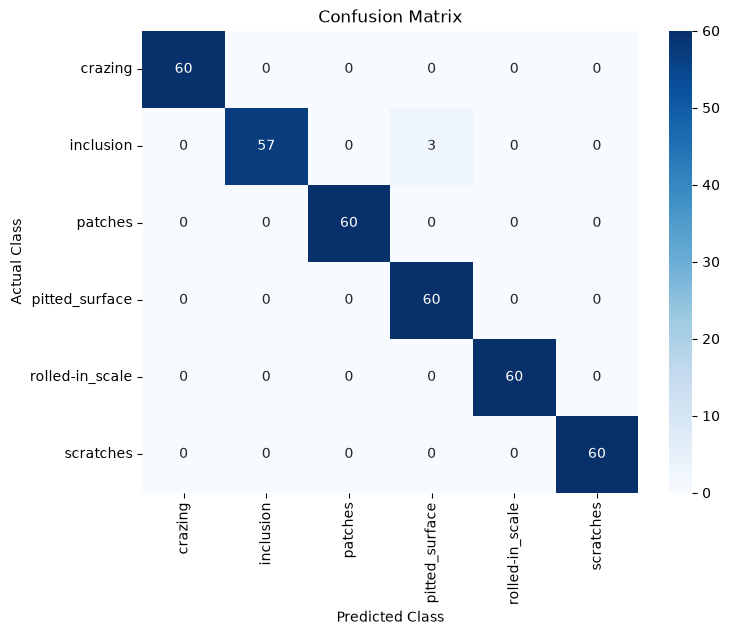

In [6]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=val_dataset.classes,
    yticklabels=val_dataset.classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()

## Model Performance Summary

- The ResNet18 model achieved 99.17% validation accuracy.
- Precision, Recall, and F1-Score values remained close to 1.00 for all defect classes.
- Only minor misclassifications were observed in the inclusion and pitted_surface categories.
- Transfer Learning significantly improved performance compared to the baseline CNN model.
- The model demonstrates strong generalization capability for automated defect classification.

## Comparison with Baseline CNN

| Model | Validation Accuracy |
|---------|---------|
| Custom CNN | 74.44% |
| ResNet18 | 99.17% |

## Key Conclusion

The implementation of Transfer Learning using ResNet18 resulted in a substantial improvement over the baseline CNN model. The pretrained architecture successfully extracted meaningful visual features and achieved near-perfect defect classification performance. Therefore, ResNet18 was selected as the final model for deployment in the visual defect detection system.